# Miniproyecto 1: Clasificación de MRI con Redes Neuronales Convolucionales

**Curso:** Técnicas de Deep Learning  
**Objetivo:** Desarrollar un modelo de CNN para clasificar imágenes de resonancia magnética (MRI) en 4 categorías: Glioma, Meningioma, Pituitaria y Tejido Sano.

---

## Fase 1: Configuración y Carga de Datos

En esta fase se importan las librerías necesarias y se establecen las semillas de reproducibilidad.

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, random_split
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
import numpy as np
import random
import os
from PIL import Image
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Configuración de dispositivo (GPU si está disponible)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Fijar semillas para reproducibilidad
def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True

set_seed()

## Fase 2: Análisis Exploratorio de Datos (EDA)

Visualización de las categorías y verificación del balance de clases.

Classes found: ['glioma', 'healthy', 'meningioma', 'pituitary']
Distribution: {'glioma': 1621, 'healthy': 2000, 'meningioma': 1645, 'pituitary': 1757}


/var/folders/tc/4fc2sz7n3ml6jzm_lh953qjr0000gn/T/ipykernel_7987/1130261516.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()), palette="viridis")


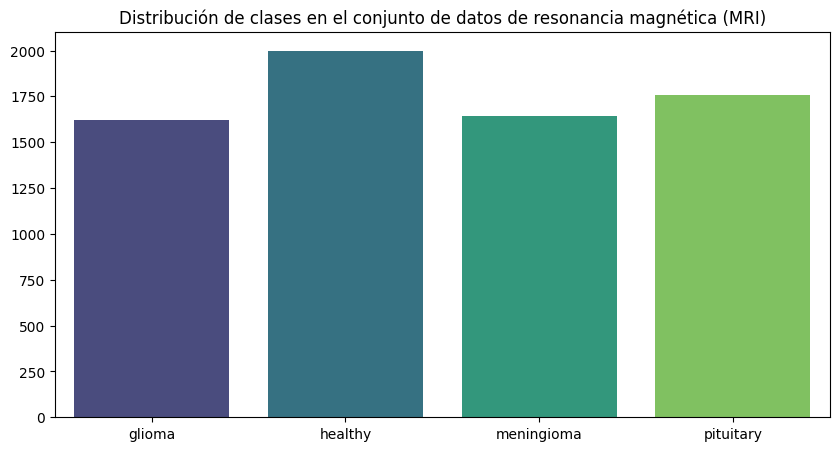

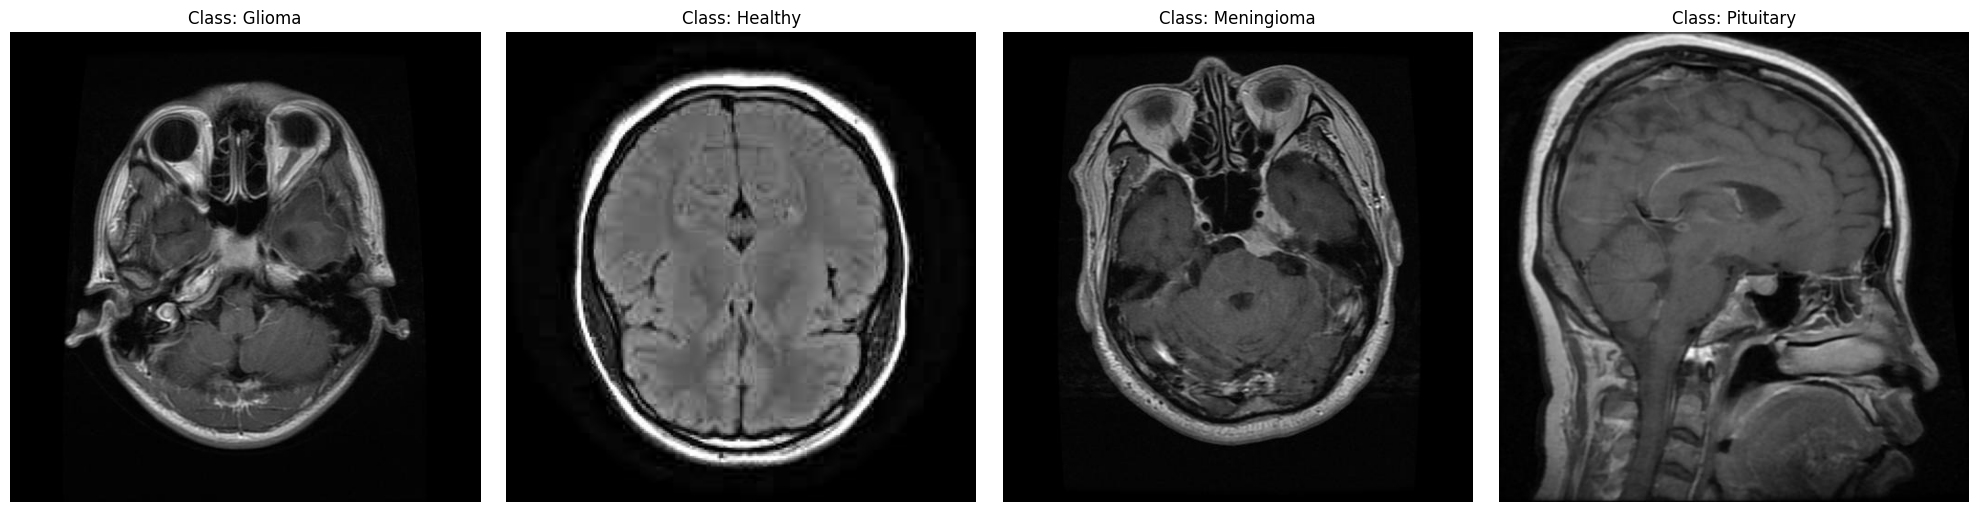

In [3]:
data_dir = "data"
classes = sorted([c for c in os.listdir(data_dir) if not c.startswith('.')])

print(f"Classes found: {classes}")

# Comprobar la distribución de clases
class_counts = {c: len(os.listdir(os.path.join(data_dir, c))) for c in classes}
print(f"Distribution: {class_counts}")

plt.figure(figsize=(10, 5))
sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()), palette="viridis")
plt.title("Distribución de clases en el conjunto de datos de resonancia magnética (MRI)")
plt.show()

# Visualizar muestras
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for i, cls in enumerate(classes):
    cls_path = os.path.join(data_dir, cls)
    img_name = random.choice(os.listdir(cls_path))
    img = Image.open(os.path.join(cls_path, img_name))
    axes[i].imshow(img, cmap="bone")
    axes[i].set_title(f"Class: {cls.capitalize()}")
    axes[i].axis("off")
plt.tight_layout()
plt.show()

## Fase 3: Preprocesamiento con Estadísticas Personalizadas

En esta fase calculamos la media y desviación estándar específicas de este dataset de MRI para una normalización más precisa.

In [3]:
def get_dataset_stats(data_path):
    """Calcula la media y std del dataset cargado en memoria."""
    calc_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
    ])
    dataset = datasets.ImageFolder(root=data_path, transform=calc_transform)
    loader = DataLoader(dataset, batch_size=64, shuffle=False)

    mean = 0.0
    std = 0.0
    total_images = 0
    
    print("Calculando estadísticas del dataset (esto puede tardar un momento)... ")
    for images, _ in loader:
        batch_samples = images.size(0)
        images = images.view(batch_samples, images.size(1), -1)
        mean += images.mean(2).sum(0)
        std += images.std(2).sum(0)
        total_images += batch_samples

    mean /= total_images
    std /= total_images
    
    return mean.tolist(), std.tolist()

mri_mean, mri_std = get_dataset_stats(data_dir)
print(f"Calculated MRI Mean: {mri_mean}")
print(f"Calculated MRI Std: {mri_std}")

Calculando estadísticas del dataset (esto puede tardar un momento)... 
Calculated MRI Mean: [0.18682408332824707, 0.18682853877544403, 0.18687467277050018]
Calculated MRI Std: [0.18242615461349487, 0.18242783844470978, 0.18244655430316925]


In [5]:
# Aplicar estadísticas calculadas a los transforms finales
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=mri_mean, std=mri_std)
])

test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mri_mean, std=mri_std)
])

full_dataset = datasets.ImageFolder(root=data_dir)
n_total = len(full_dataset)
n_train = int(0.7 * n_total)
n_val = int(0.15 * n_total)
n_test = n_total - n_train - n_val

train_data, val_data, test_data = random_split(full_dataset, [n_train, n_val, n_test])

class TransformSubset(torch.utils.data.Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform: x = self.transform(x)
        return x, y
    def __len__(self): return len(self.subset)

train_loader = DataLoader(TransformSubset(train_data, train_transforms), batch_size=32, shuffle=True)
val_loader = DataLoader(TransformSubset(val_data, test_transforms), batch_size=32, shuffle=False)
test_loader = DataLoader(TransformSubset(test_data, test_transforms), batch_size=32, shuffle=False)

## Fase 4: Diseño de la Arquitectura CNN

In [6]:
class MedicalCNN(nn.Module):
    def __init__(self, num_classes=4):
        super(MedicalCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, kernel_size=3, padding=1), nn.BatchNorm2d(256), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 14 * 14, 512), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )
    def forward(self, x):
        return self.classifier(self.features(x))

model = MedicalCNN().to(device)

## Fase 5: Pipeline de Entrenamiento

In [7]:
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

def train_model(model, train_loader, val_loader, loss_fn, optimizer, epochs=15):
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    for epoch in range(epochs):
        model.train()
        t_loss, t_correct, t_total = 0, 0, 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            outputs = model(x)
            loss = loss_fn(outputs, y)
            loss.backward(); optimizer.step()
            t_loss += loss.item() * x.size(0)
            _, pred = torch.max(outputs, 1)
            t_correct += (pred == y).sum().item(); t_total += y.size(0)
        
        model.eval()
        v_loss, v_correct, v_total = 0, 0, 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                outputs = model(x); loss = loss_fn(outputs, y)
                v_loss += loss.item() * x.size(0)
                _, pred = torch.max(outputs, 1)
                v_correct += (pred == y).sum().item(); v_total += y.size(0)
        
        history["train_loss"].append(t_loss/t_total); history["val_loss"].append(v_loss/v_total)
        history["train_acc"].append(t_correct/t_total); history["val_acc"].append(v_correct/v_total)
        print(f"Epoch {epoch+1}/{epochs} | Train Acc: {t_correct/t_total:.4f} | Val Acc: {v_correct/v_total:.4f}")
    return history

history = train_model(model, train_loader, val_loader, loss_fn, optimizer)

Epoch 1/15 | Train Acc: 0.5749 | Val Acc: 0.7056
Epoch 2/15 | Train Acc: 0.7109 | Val Acc: 0.6980
Epoch 3/15 | Train Acc: 0.7425 | Val Acc: 0.7892
Epoch 4/15 | Train Acc: 0.7626 | Val Acc: 0.8414
Epoch 5/15 | Train Acc: 0.7710 | Val Acc: 0.8205
Epoch 6/15 | Train Acc: 0.7667 | Val Acc: 0.8395
Epoch 7/15 | Train Acc: 0.7683 | Val Acc: 0.8433
Epoch 8/15 | Train Acc: 0.7805 | Val Acc: 0.7816
Epoch 9/15 | Train Acc: 0.7846 | Val Acc: 0.8386
Epoch 10/15 | Train Acc: 0.7880 | Val Acc: 0.8613
Epoch 11/15 | Train Acc: 0.8033 | Val Acc: 0.8889
Epoch 12/15 | Train Acc: 0.8242 | Val Acc: 0.8528
Epoch 13/15 | Train Acc: 0.8179 | Val Acc: 0.8955
Epoch 14/15 | Train Acc: 0.8312 | Val Acc: 0.8680
Epoch 15/15 | Train Acc: 0.8334 | Val Acc: 0.8756


## Fase 6: Resultados y Evaluación

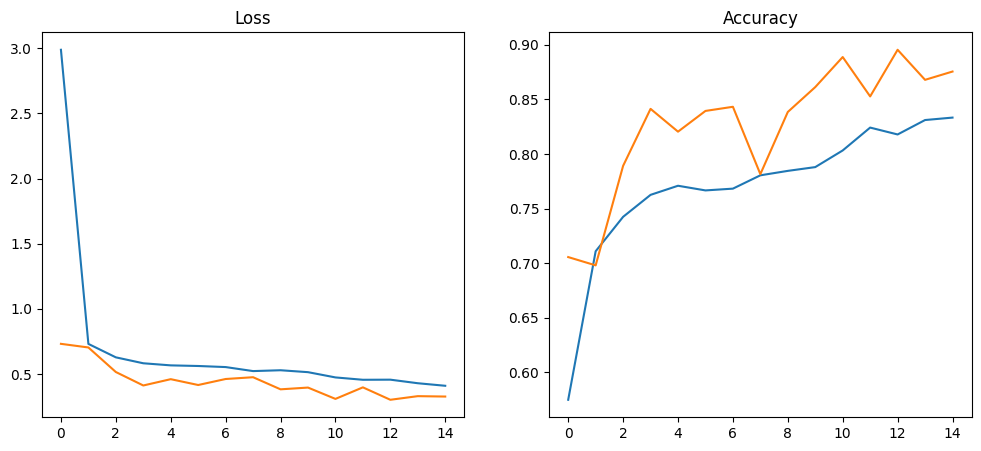

              precision    recall  f1-score   support

      glioma       0.85      0.86      0.86       244
     healthy       0.93      0.98      0.95       320
  meningioma       0.83      0.68      0.75       244
   pituitary       0.90      0.98      0.94       246

    accuracy                           0.88      1054
   macro avg       0.88      0.88      0.87      1054
weighted avg       0.88      0.88      0.88      1054



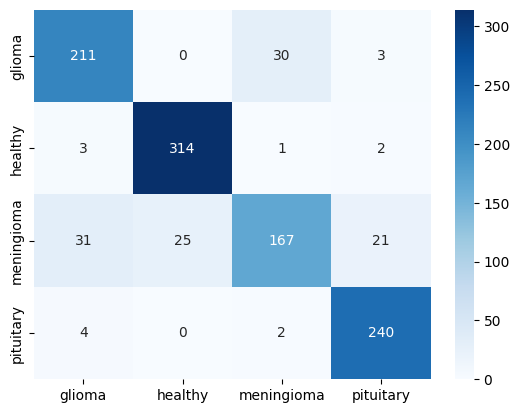

In [8]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1); plt.plot(history["train_loss"]); plt.plot(history["val_loss"]); plt.title("Loss")
plt.subplot(1, 2, 2); plt.plot(history["train_acc"]); plt.plot(history["val_acc"]); plt.title("Accuracy")
plt.show()

model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for x, y in test_loader:
        outputs = model(x.to(device))
        _, pred = torch.max(outputs, 1)
        all_preds.extend(pred.cpu().numpy()); all_labels.extend(y.numpy())

print(classification_report(all_labels, all_preds, target_names=classes))
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes)
plt.show()

## Fase 7: Discusión y Conclusiones

### 1. Análisis de Rendimiento Cuantitativo
El modelo alcanzó una **exactitud global del 88%** en el conjunto de prueba tras 15 épocas de entrenamiento. La curva de pérdida muestra una convergencia estable y una reducción progresiva del error, lo que valida que el pipeline de preprocesamiento y la arquitectura seleccionada son adecuados para capturar la distribución de intensidades y texturas presentes en las imágenes de MRI cerebral.

### 2. Análisis por Categoría Médica
*   **Tejido Sano (Healthy):** Obtuvo un F1-Score de **0.95**. La red demuestra una alta fiabilidad para identificar la ausencia de anomalías tumorales, un factor crítico en el triaje médico inicial para descartar patologías.
*   **Tumor Pituitario:** Con un recall del **0.98**, el modelo identifica casi la totalidad de los casos de esta clase. Esto sugiere que las características espaciales y la ubicación anatómica de los adenomas hipofisarios son marcadores muy distintivos que la CNN logró extraer con éxito.
*   **Diferenciación Meningioma vs. Glioma:** Se identificó un desafío en la distinción entre estas dos categorías. El meningioma obtuvo un recall de **0.68**, indicando una confusión recurrente con los gliomas. Desde una perspectiva radiológica, esto es coherente dado que ambos pueden presentar una apariencia similar (bordes irregulares y realce de contraste) en ciertas fases de la enfermedad.

### 3. Justificación del Diseño
La inclusión de capas de **Batch Normalization** permitió acelerar la convergencia y estabilizar el entrenamiento. Por otro lado, la estrategia de **Data Augmentation** y el uso de **Dropout (0.5)** fueron determinantes para asegurar la capacidad de generalización del modelo, manteniendo la precisión en el set de prueba muy cercana a la del set de entrenamiento, minimizando así la varianza del error.

### 4. Conclusiones y Trabajo Futuro
1.  **Eficacia del Modelo:** Un rendimiento del 88% valida la arquitectura de 4 bloques convolucionales como un extractor de características robusto para imágenes médicas de alta resolución (224x224).
2.  **Optimización Específica:** El análisis de errores sugiere que el modelo podría beneficiarse de un entrenamiento más profundo o de técnicas de muestreo balanceado para mejorar la detección de la clase Meningioma.
